# **Problem Statement**

**Austo Motor Company** is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.
They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('../data/austo_automobile.csv')
df = data.copy()


In [2]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [3]:
df.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.0,31600,31000,Hatchback


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   str    
 2   Profession        1581 non-null   str    
 3   Marital_status    1581 non-null   str    
 4   Education         1581 non-null   str    
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   str    
 7   House_loan        1581 non-null   str    
 8   Partner_working   1581 non-null   str    
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   str    
dtypes: float64(1), int64(5), str(8)
memory usage: 173.1 KB


In [5]:
df.shape

(1581, 14)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


In [8]:
df.isnull().sum()

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

### **Checking for missing values in the Gender column**

In [9]:
df['Gender'].value_counts(dropna = False)

Gender
Male      1199
Female     327
NaN         53
Femal        1
Femle        1
Name: count, dtype: int64

In [10]:
df['Gender'] = df['Gender'].replace({'Femal':'Female','Femle':'Female'})
df['Gender'].value_counts(dropna = False)

Gender
Male      1199
Female     329
NaN         53
Name: count, dtype: int64

**--- Gender is categorial, therefore can fill it by mode method**

In [11]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace = True)

/tmp/ipykernel_591/131057347.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0], inplace = True)


0         Male
1       Female
2       Female
3       Female
4         Male
         ...  
1576      Male
1577      Male
1578      Male
1579      Male
1580      Male
Name: Gender, Length: 1581, dtype: str

In [12]:
df['Gender'].value_counts()

Gender
Male      1199
Female     329
Name: count, dtype: int64

### **Checking for null values in the Partner Salary column**

In [13]:
df[df['Partner_salary'].isnull()]['Partner_working'].value_counts()

Partner_working
No     90
Yes    16
Name: count, dtype: int64

**--- If the partner working is 'No', partner salary must be 0**

In [14]:
df.loc[(df['Partner_working'] == 'No') & (df['Partner_salary'].isnull()), 'Partner_salary'] = 0

In [15]:
df[df['Partner_salary'].isnull()]['Partner_working'].value_counts()

Partner_working
Yes    16
Name: count, dtype: int64

**--- Since we know the total salary, we can derive the partner salary by deducting the total salary by the salary where partner salary is 'Yes'**

In [16]:
df.loc[(df['Partner_working'] == 'Yes') & (df['Partner_salary'].isnull()), 'Partner_salary'] = df['Total_salary'] - df['Salary']

In [17]:
df.isnull().sum()

Age                  0
Gender              53
Profession           0
Marital_status       0
Education            0
No_of_Dependents     0
Personal_loan        0
House_loan           0
Partner_working      0
Salary               0
Partner_salary       0
Total_salary         0
Price                0
Make                 0
dtype: int64

### ***Univariate Analysis***

### a) Which automobile make is the most preferred?

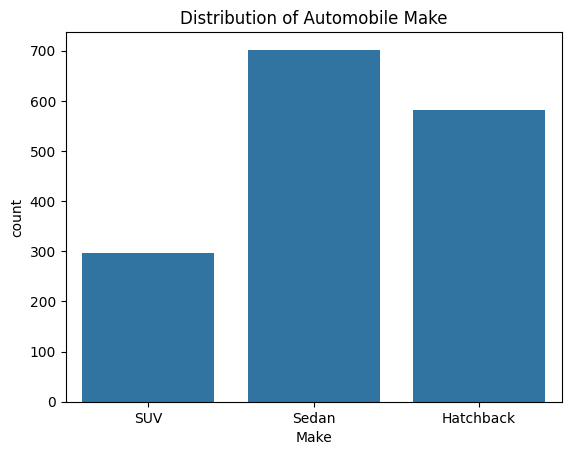

In [18]:
sns.countplot(data = df, x = 'Make')
plt.title('Distribution of Automobile Make');

*   It is evident that **Sedan** is the most preferred automobile make with the highest count, followed by Hatchback, while SUV records the lowest preference among the three categories.




### b) What is the Gender distribution of the customers?

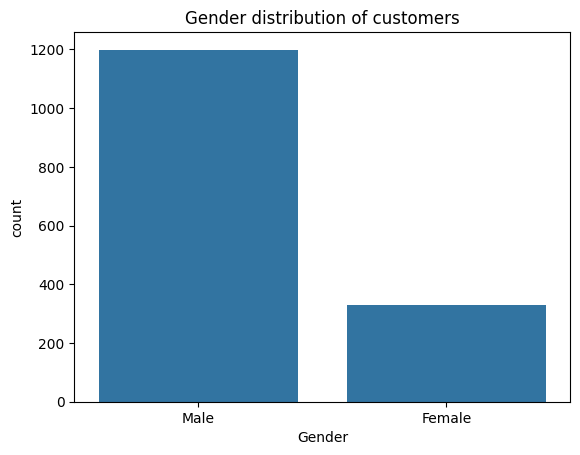

In [19]:
sns.countplot(data = df, x = 'Gender')
plt.title('Gender distribution of customers');

*   Males dominate the automobile market, accounting for a significantly larger share of customers compared to females.


### c) What is the profession of the customers?

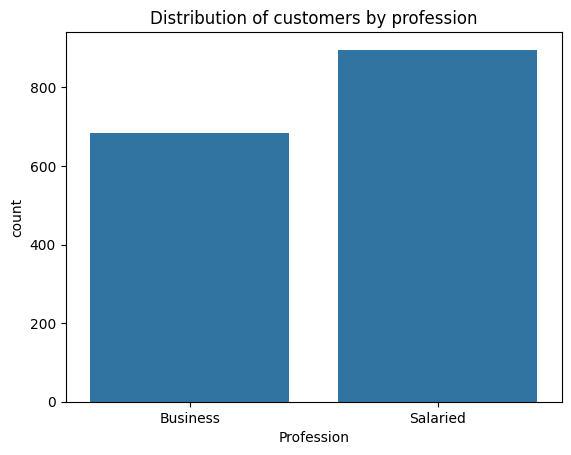

In [20]:
sns.countplot(data = df, x = 'Profession')
plt.title('Distribution of customers by profession');



*   Salaried professionals represent the largest customer segment in the automobile market, outnumbering business professionals by a considerable margin, highlighting them as the primary target audience.


### d) Marital status of the customers?

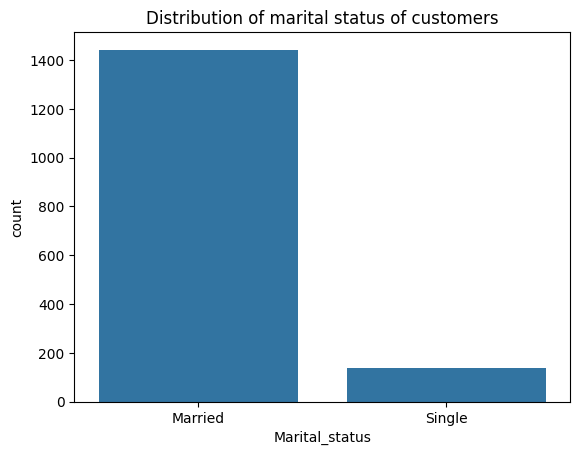

In [21]:
sns.countplot(data = df, x = 'Marital_status')
plt.title('Distribution of marital status of customers');



*  Married customers constitute to the dominant segment of buyers, significantly outnumbering their single counterparts.


### e) What is the Educational qualification  of the customers?


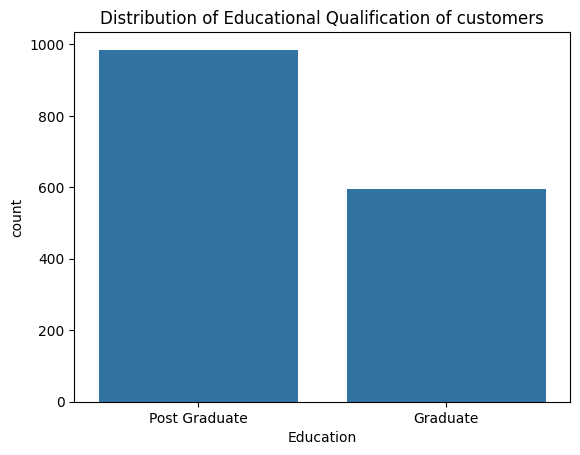

In [22]:
sns.countplot(data = df, x = 'Education')
plt.title('Distribution of Educational Qualification of customers');



* Postgraduates represent the largest and most dominant segment of automobile buyers.


### f) What percentage of the customers take personal loans?

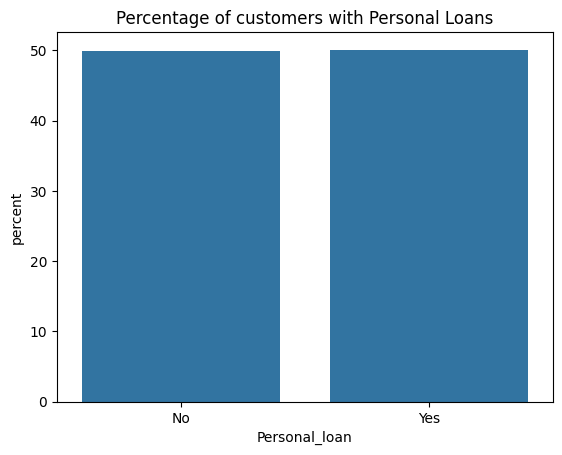

In [23]:
sns.countplot(data = df, x = 'Personal_loan', stat = 'percent')
plt.title('Percentage of customers with Personal Loans');



*   Data reveals equal distribution between customers who have taken personal loans and who have not, with each group accounting for approx. 50% of the total dataset.


### g) What percentage of the customers take house loans?

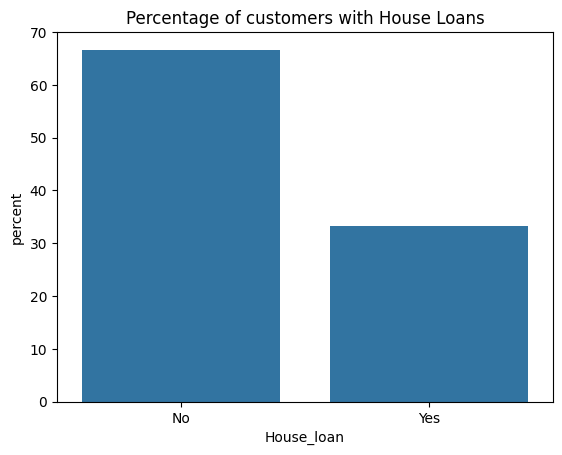

In [24]:
sns.countplot(data = df, x = 'House_loan', stat = 'percent')
plt.title('Percentage of customers with House Loans');



*   The customers who have not taken house loans are significantly largeer compared to those who have, therefore most customers remain unleveraged in terms of housing finance


### h) What percentage of the customers have a partner who is working?

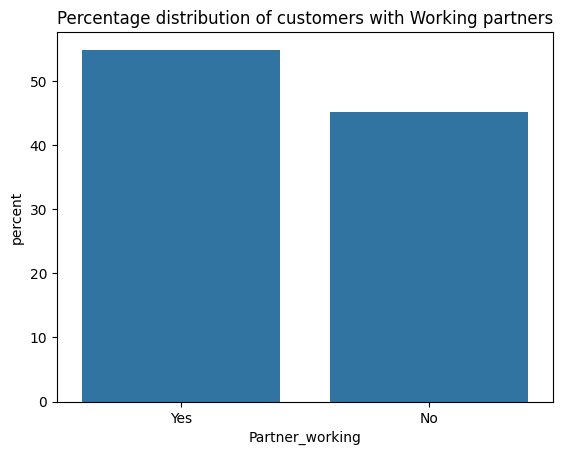

In [25]:
sns.countplot(data = df, x = 'Partner_working', stat = 'percent')
plt.title('Percentage distribution of customers with Working partners');



*   Customer's with working parterns are in the majority, with a minor margin of nearly 4% difference to those who dont have a working partner.


### i) What is the age group of the cutomers and what are their preferrences?

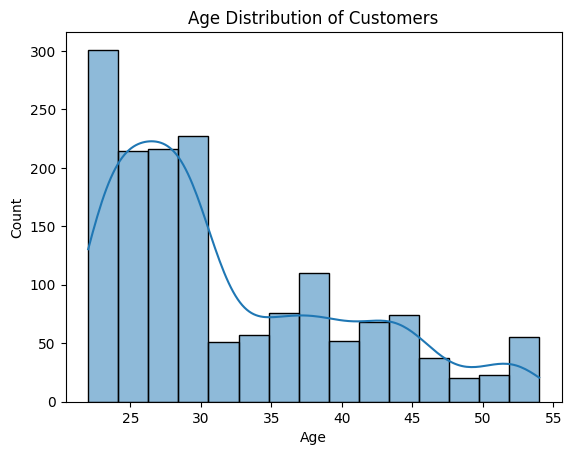

In [26]:
sns.histplot(data = df, x = 'Age', kde = True)
plt.title('Age Distribution of Customers');


*   The histogram indicates a right-skewed age distribution. The highest number of customers falls in the 25–30 age group, and the frequency gradually declines from the 35–55 range.

### j) What is the salary distribution of the customers?

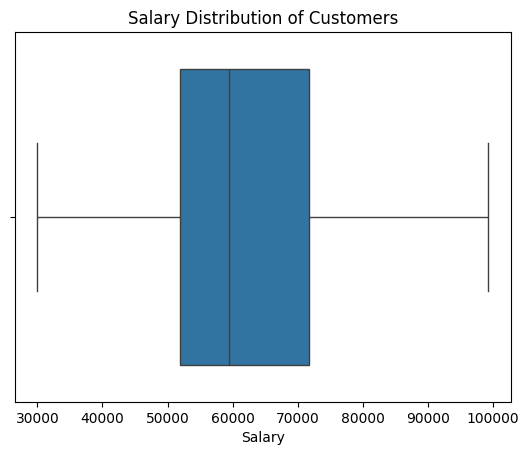

In [27]:
sns.boxplot(data = df, x = 'Salary')
plt.title('Salary Distribution of Customers');



*   Median customer salary is approximately 60,000, with most customers earning between 52,000 and 72,000.
*   Salaries range from 30,000 to 100,000, indicating a diverse customer income base, and no significant outliers are observed.


### k) What is the distribution of the partner salary?

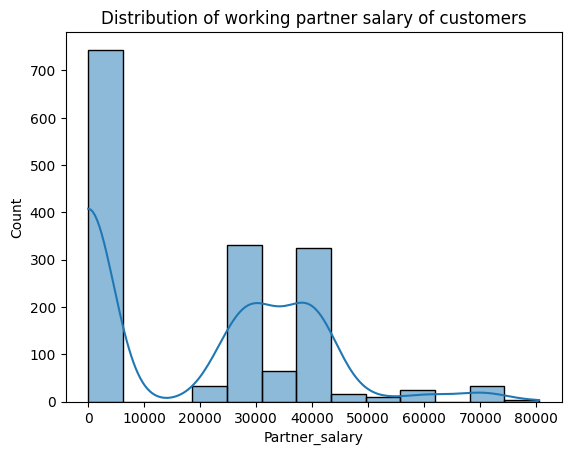

In [28]:
sns.histplot(data = df, x = 'Partner_salary', kde = True)
plt.title('Distribution of working partner salary of customers');

*  The distribution is highly right-skewed, with a large concentration of values at the lower end, while a smaller group of customers has partner salaries ranging from 25,000 to 45,000 and a few high-incomers extending upto 80,000

### m) What is the distribution of Total Salary of customers?

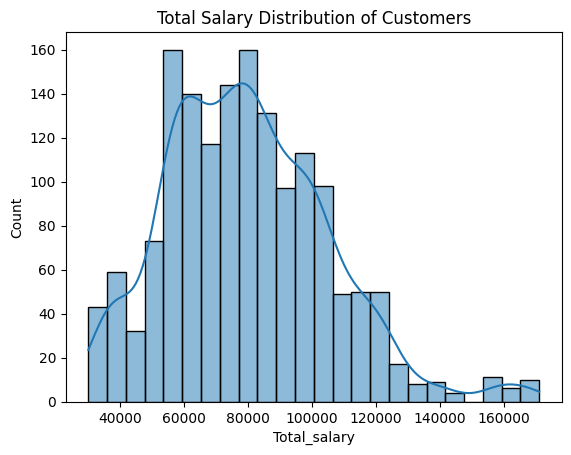

In [29]:
sns.histplot(data = df, x = 'Total_salary', kde = True)
plt.title('Total Salary Distribution of Customers');

*   The distribution of total salary is right skewed, with most customers having a total salary between 50,000 and 100,000, while a smaller number of customers earn substantially higher incomes

### n) What is the distribution of price of automobiles?

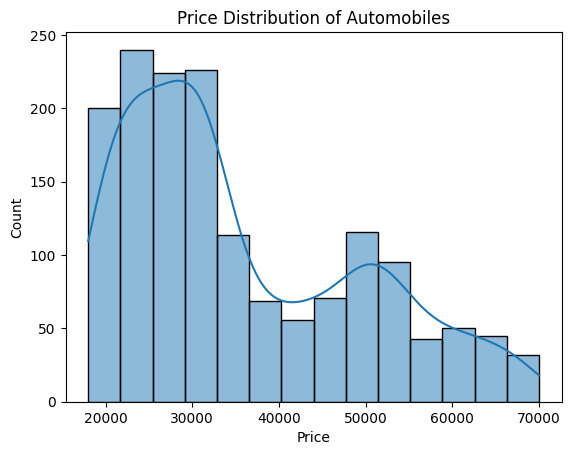

In [30]:
sns.histplot(data = df, x = 'Price', kde = True)
plt.title('Price Distribution of Automobiles');

*  The price distribution of automobiles is also positively skewed with most of the models lie in the range of 20,000 and 35,000.
*  The distribution is extended to 70,000 by a small number of high priced vehicles and can conclude that the lower and mid ranged automobile attract customers.

## ***Bivariate Analysis***

### a) How does Gender influence automobile buying behavior?

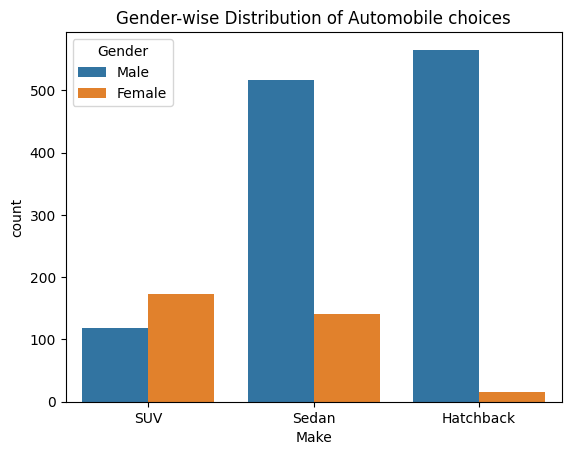

In [31]:
sns.countplot(data = df, x = 'Make', hue = 'Gender')
plt.title('Gender-wise Distribution of Automobile choices');



*   The data reveals a clear gender-based distinction in automobile preferences. Males demonstrate a stronger inclination toward Sedans and Hatchbacks, whereas females show a significantly higher preference for SUVs.



### b) How does Profession influence automobile sale?

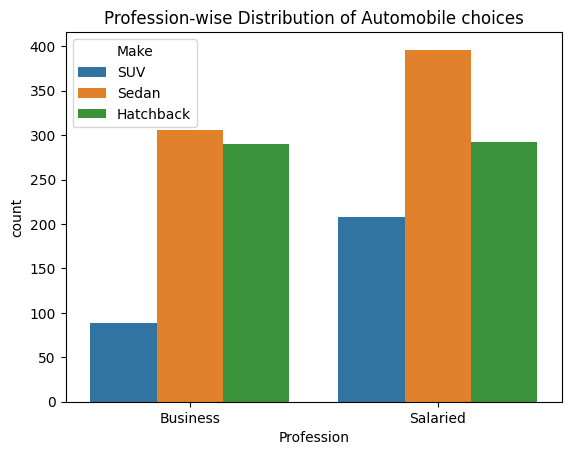

In [32]:
sns.countplot(data = df, x = 'Profession', hue = 'Make')
plt.title('Profession-wise Distribution of Automobile choices');



*   The data indicates that **Sedan** is the most preferred automobile type across both professions, with the highest preference observed among **Salaried** individuals. This is followed by **Hatchback** and **SUV**, which rank second and third, respectively, in both the Business and Salaried categories.



### c) How does Marital Status influence automobile purchasing behavior?

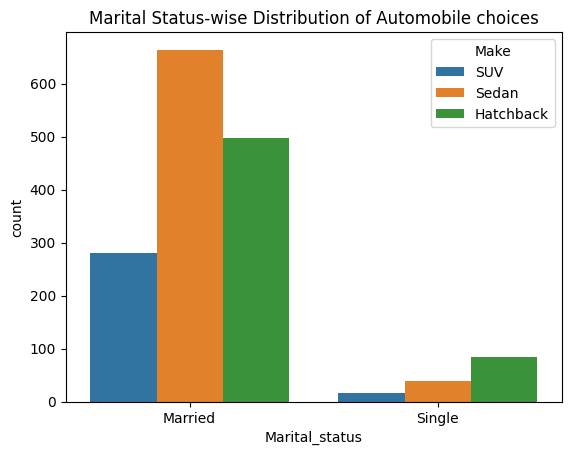

In [33]:
sns.countplot(data = df, x = 'Marital_status', hue = 'Make')
plt.title('Marital Status-wise Distribution of Automobile choices');



*   Data reveals that Sedans are highly preferred by married individuals, followed by Hatchbacks and then SUVs. In contrast, among Singles, Hatchbacks are the most preferred, with Sedan and SUV following closely.


### d) How does number of dependents affect automobile sales?

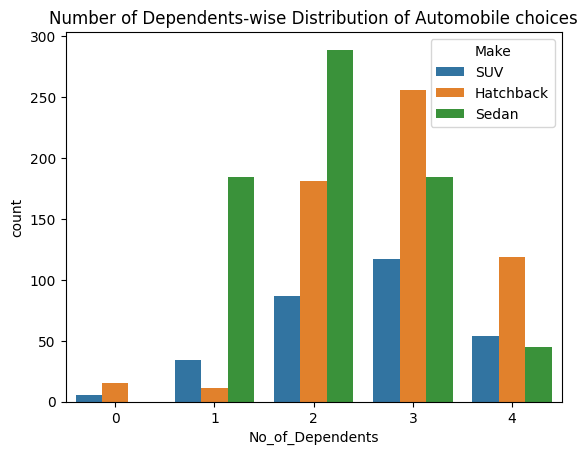

In [34]:
sns.countplot(data = df, x = 'No_of_Dependents', hue = 'Make')
plt.title('Number of Dependents-wise Distribution of Automobile choices');

*  The distribution is slightly negatively (left) skewed and customers with 2-3 dependents contribute to most of the automobile purchases in all the vehicle segments.
*  Customers with 1–2 dependents are most likely to purchase sedans, whereas customers with 3–4 dependents mostly buy hatchbacks.
*  All dependent groups have low SUV purchases, but are highest with customers with 3 dependents.

### e) How does age of the customer influence automobile purchasing behvaior?

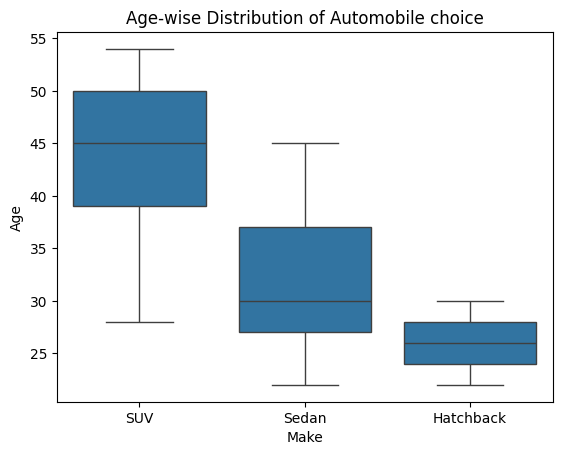

In [35]:
sns.boxplot(data = df, y = 'Age', x = 'Make')
plt.title('Age-wise Distribution of Automobile choice');


*   Customer age distribution varies significantly across vehicle segments.
*   SUV buyers exhibit the widest age range, spanning approximately 28 to 54 years, indicating broad appeal across different age groups.
*   Sedan customers are generally younger, with ages ranging from about 22 to 45 years.
*   Hatchback buyers show the narrowest age distribution, primarily concentrated between 22 and 30 years, suggesting that this segment is most popular among younger customers.


### f) What is the relationship between a customer's salary and their preferred automobile make?

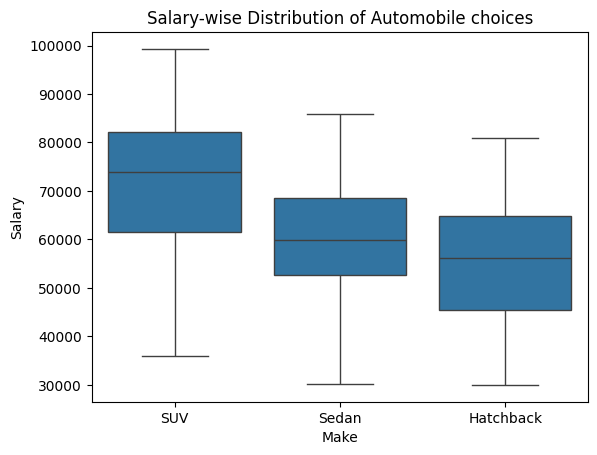

In [36]:
sns.boxplot(data = df, y ='Salary', x = 'Make')
plt.title('Salary-wise Distribution of Automobile choices');



*   SUV buyers demonstrate the highest salary range, with median salaries approximately between 65,000 and 80,000, suggesting a preference among higher-income customers.
*   Sedan customers exhibit a moderate salary range, with median values concentrated around 60,000 to 70,000.
*   Hatchback buyers display the lowest salary distribution, with median salaries ranging from approximately 55,000 to 65,000, indicating that this segment is predominantly favored by budget-conscious customers.





### g) What is the price range of the category of automobile?

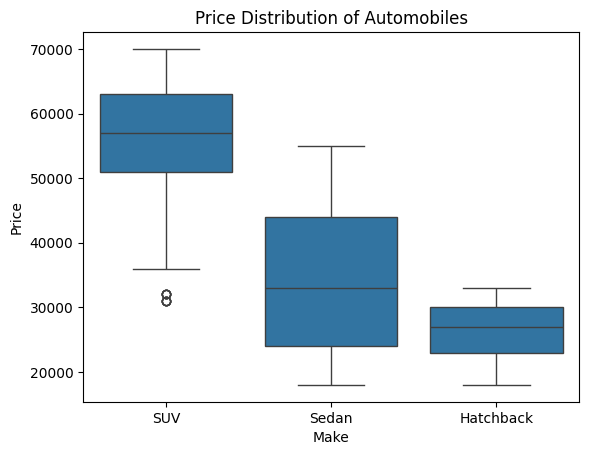

In [37]:
sns.boxplot(data = df, y = 'Price', x = 'Make')
plt.title('Price Distribution of Automobiles');

* SUVs are the highest-priced vehicle segment, with a median price of approximately 57,000 and a wider price range compared to other segments.
* Sedans occupy the mid-price range, while Hatchbacks are the most affordable, exhibiting the lowest median price.
* A few lower-priced SUV outliers are also observed.

### h) What is the relationship between a customer's total salary and their choice of automobile?

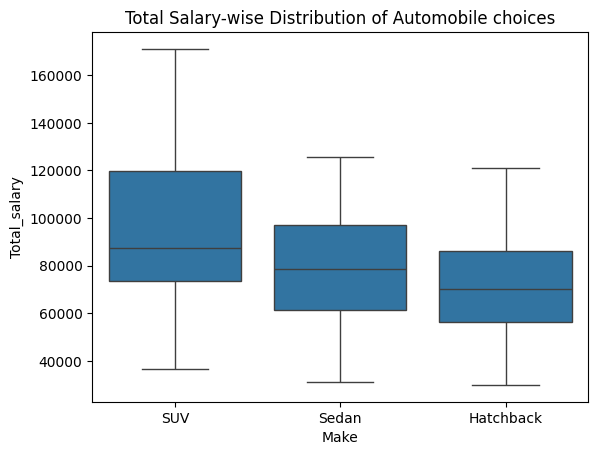

In [38]:
sns.boxplot(data = df, x = 'Make', y = 'Total_salary')
plt.title('Total Salary-wise Distribution of Automobile choices');

* Customers purchasing SUVs tend to have higher total salaries than buyers of other vehicle segments, with a median total salary of approximately 85,000.
* Sedan buyers fall in between, while Hatchback buyers generally have the lowest total salaries.

### i) What is the distribution of the customers in each segment based on personal loans?


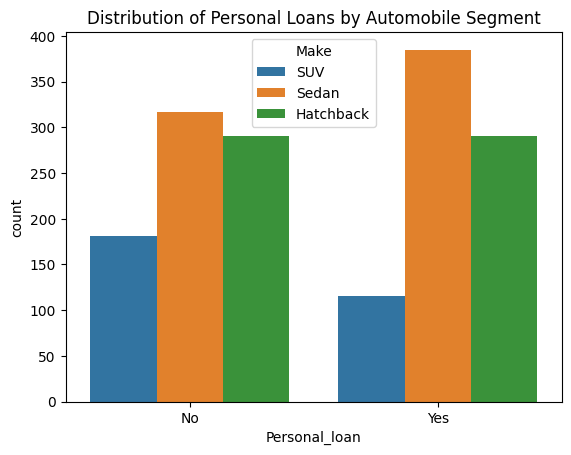

In [39]:
sns.countplot(data = df, x = 'Personal_loan', hue = 'Make')
plt.title('Distribution of Personal Loans by Automobile Segment');

* Sedans are the automobile segment that is purchased most often among customers with or without personal loan.
* Personal loan customers have a greater inclination toward buying sedans, whereas the purchases of Hatchbacks have been observed to remain steady whether a personal loan is taken or not.

### j) How does a working partner have an impact on the price of the automoblie purchased?

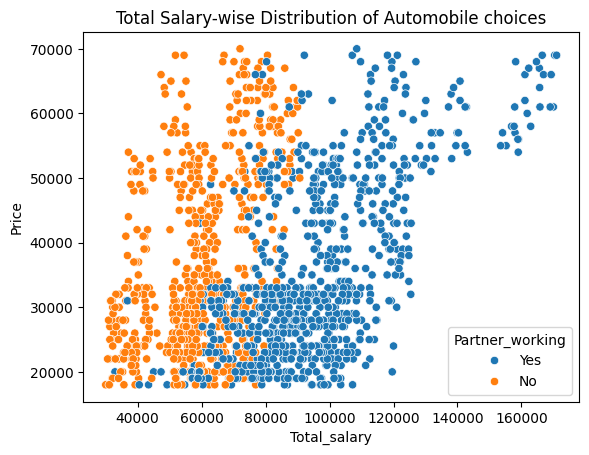

In [40]:
sns.scatterplot(data = df, x = 'Total_salary', y = 'Price', hue = 'Partner_working')
plt.title('Total Salary-wise Distribution of Automobile choices');

## ***Multivariate Analysis***

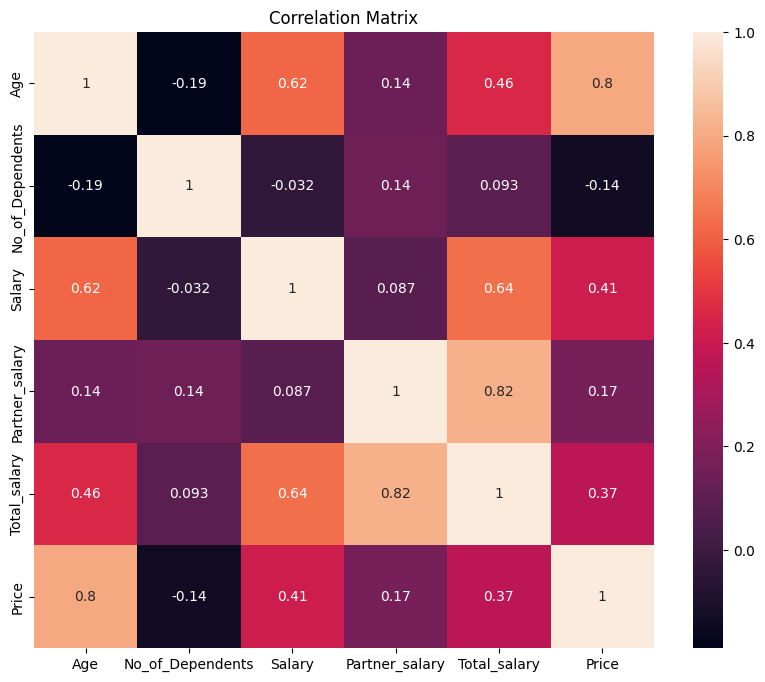

In [41]:
corr = df.corr(numeric_only = True)

plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True)
plt.title('Correlation Matrix');


### b) How does salary of a customer affect a vehicle choice?

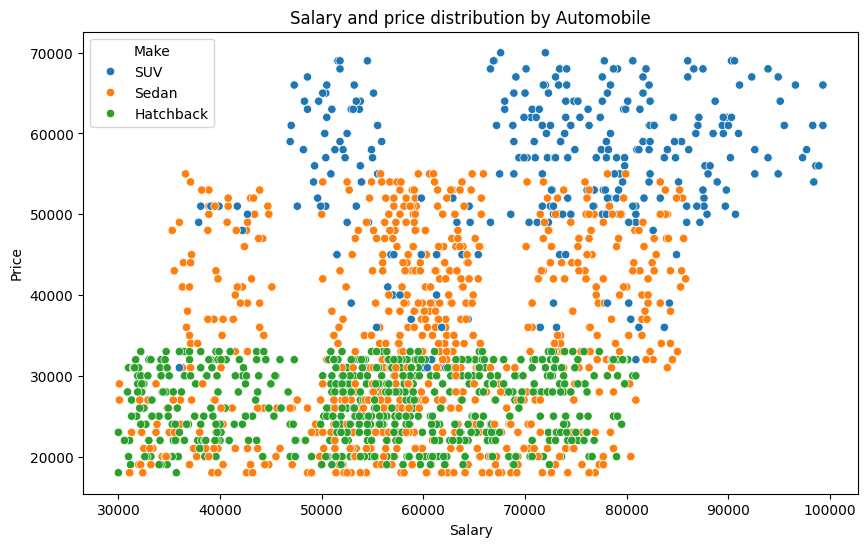

In [42]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x = 'Salary', y = 'Price', hue = 'Make')
plt.title('Salary and price distribution by Automobile');

* Higher-income customers tend to opt for higher-priced automobile segments, with SUVs being preferred choice
* Hatchbacks are dense in the lower price range, while Sedans serve as the bridge in the middle-income segment

# **Key Questions**

### Q3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for an SUV sale over a Sedan sale?

In [43]:
salaried_male = df[(df['Profession'] == 'Salaried') & (df['Gender'] == 'Male')]
salaried_male['Make'].value_counts()

Make
Sedan        279
Hatchback    276
SUV           85
Name: count, dtype: int64

### Q4. How does the amount spent on purchasing automobiles vary by gender?

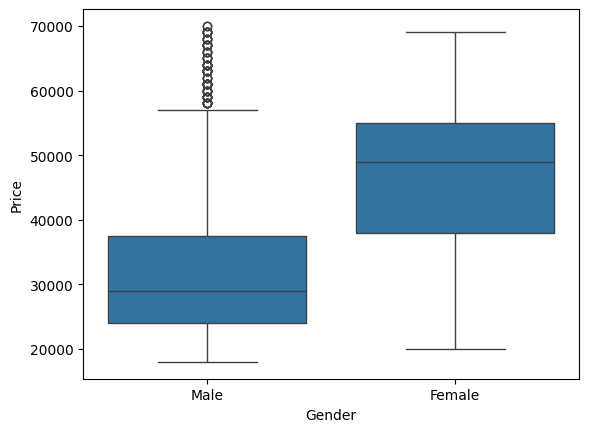

In [44]:
sns.boxplot(data = df, x = 'Gender', y = 'Price');

### Q5. How much money was spent on purchasing automobiles by individuals who took a personal loan?

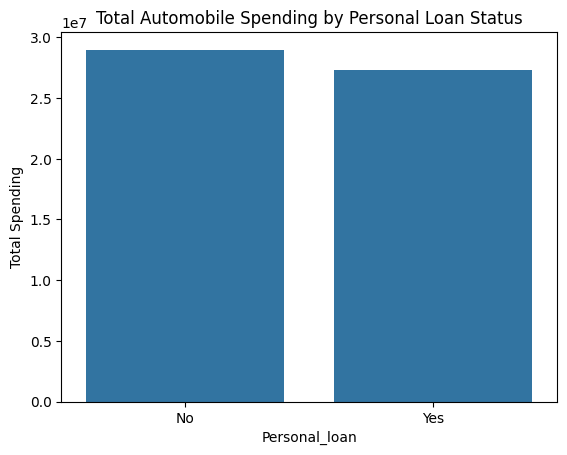

In [45]:
loan_spending = df.groupby('Personal_loan')['Price'].sum()
sns.barplot(data = loan_spending)
plt.title('Total Automobile Spending by Personal Loan Status')
plt.ylabel('Total Spending');

### Q6. How does having a working partner influence the purchase of higher-priced cars?

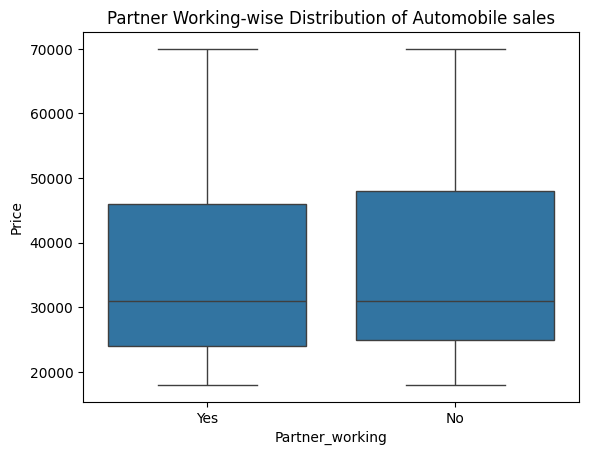

In [46]:
sns.boxplot(data = df, x = 'Partner_working', y = 'Price')
plt.title('Partner Working-wise Distribution of Automobile sales');

---
# **Statistical Validation (Extension beyond the original assignment)**

The sections above answer the assignment's key questions descriptively — by comparing counts, percentages, and eyeballing boxplots. That's useful for a first read, but claims like *"no strong influence of a working partner on price"* need a hypothesis test behind them, not just a visual impression. This section runs the actual tests to confirm (or challenge) the descriptive conclusions above.


In [47]:
from scipy import stats
import numpy as np


### 1. Does gender associate with vehicle Make? (Chi-square test of independence)
The descriptive analysis found women skew heavily toward SUVs. Testing whether this association is statistically significant, not just a sample-size artifact.

In [48]:
contingency_gender = pd.crosstab(df['Gender'], df['Make'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_gender)
print(contingency_gender)
print(f"\nChi-square statistic: {chi2:.2f}, degrees of freedom: {dof}, p-value: {p_val:.6f}")
print("Significant association between Gender and Make" if p_val < 0.05 else "No significant association")


Make    Hatchback  SUV  Sedan
Gender                       
Female         15  173    141
Male          565  118    516

Chi-square statistic: 370.86, degrees of freedom: 2, p-value: 0.000000
Significant association between Gender and Make


### 2. Does profession associate with vehicle Make?
Testing whether the Sedan preference among salaried professionals is statistically significant.

In [49]:
contingency_prof = pd.crosstab(df['Profession'], df['Make'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_prof)
print(contingency_prof)
print(f"\nChi-square statistic: {chi2:.2f}, degrees of freedom: {dof}, p-value: {p_val:.6f}")
print("Significant association between Profession and Make" if p_val < 0.05 else "No significant association")


Make        Hatchback  SUV  Sedan
Profession                       
Business          290   89    306
Salaried          292  208    396

Chi-square statistic: 31.63, degrees of freedom: 2, p-value: 0.000000
Significant association between Profession and Make


### 3. Does a working partner significantly affect purchase price? (Mann-Whitney U test)
The original boxplot comparison (Q6) concluded there's "no strong influence." Price is right-skewed, so a non-parametric test (Mann-Whitney U) is more appropriate here than a t-test, which assumes normally distributed data.

In [50]:
price_partner_yes = df[df['Partner_working'] == 'Yes']['Price']
price_partner_no = df[df['Partner_working'] == 'No']['Price']

u_stat, p_val = stats.mannwhitneyu(price_partner_yes, price_partner_no, alternative='two-sided')
print(f"Median price (partner working): {price_partner_yes.median():.0f}")
print(f"Median price (partner not working): {price_partner_no.median():.0f}")
print(f"Mann-Whitney U statistic: {u_stat:.2f}, p-value: {p_val:.6f}")
print("Statistically significant difference" if p_val < 0.05 else "Confirms: no statistically significant difference")


Median price (partner working): 31000
Median price (partner not working): 31000
Mann-Whitney U statistic: 300358.00, p-value: 0.314339
Confirms: no statistically significant difference


### 4. Is total automobile spending significantly different between personal-loan holders and non-holders?
Q5 compared total spending (a sum, which is sensitive to group size) between the two groups. Testing the per-customer price distribution instead, which controls for the fact that the two groups aren't necessarily the same size.

In [51]:
price_loan_yes = df[df['Personal_loan'] == 'Yes']['Price']
price_loan_no = df[df['Personal_loan'] == 'No']['Price']

u_stat, p_val = stats.mannwhitneyu(price_loan_yes, price_loan_no, alternative='two-sided')
print(f"Group sizes -> loan: {len(price_loan_yes)}, no loan: {len(price_loan_no)}")
print(f"Median price (loan): {price_loan_yes.median():.0f}")
print(f"Median price (no loan): {price_loan_no.median():.0f}")
print(f"Mann-Whitney U statistic: {u_stat:.2f}, p-value: {p_val:.6f}")
print("Statistically significant difference in per-customer spending" if p_val < 0.05 else "No statistically significant difference in per-customer spending")


Group sizes -> loan: 792, no loan: 789
Median price (loan): 31000
Median price (no loan): 32000
Mann-Whitney U statistic: 287763.00, p-value: 0.006516
Statistically significant difference in per-customer spending


### Takeaway
The chi-square tests confirm the gender–Make and profession–Make associations from the descriptive section are statistically significant, not sampling noise. The Mann-Whitney tests are what actually validate (or don't) the "no strong influence" and personal-loan spending conclusions from the original report — run the cells above to see the p-values for this dataset.